# Installing packages

In [1]:
!pip install pnadium
!pip install xlrd>=2.0.1

# Loading packages

In [3]:
import pnadium
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.tree import plot_tree
from sklearn.linear_model import LinearRegression

# LoadingDataset

In [5]:
pnad = pnadium.trimestral.download(ano=2025, t=2, colunas=['V2007', 'V2009', 'VD4019', 'VD4002', 'VD3005', 'VD4007', 'VD2003', 'V2001', 'VD4014', 'VD2004']) # loading the DS
# Survey from 2nd Quarter of 2025!

Iniciou o download: Trimestre 2/2025 - aguarde.
Download finalizado.
Iniciou a criação do DataFrame Pandas: esta etapa pode demorar alguns minutos.
Chunks processados e salvos.
DataFrame criado.


Explanation of each variable:
- V2007: Gender 
- V2009: Age 
- VD4019: Total income per capita 
- VD4002: Working VS. NOT WORKING 
- VD3005: Years of study 
- VD4007: Type of occupation: employee, employer, self-employed, etc 
- VD2003: Number of people in the house 
- V2001: Amount of people in the house excluding domestic workers, retirees, etc. 
- VD4014: Amount of hours worked (range) 
- VD2004: Condition of the house 


422 variables total, so I had to select the most interesting ones

Documentation: https://www.ibge.gov.br/en/statistics/social/labor/2866-np-continuous-national-household-sample-survey/31241-pnadc-pnadc4-en.html?=&t=conceitos-e-metodos 

# Exploring and Cleaning Dataset

In [11]:
df = pnad.drop(['UPA', 'V1008', 'V1014', 'V2003', 'COD_FAM', 'COD_PESSOA'], axis=1) # Dropping unnecessary features
df.columns = ['N_People', 'Gender', 'Age', 'N_People_H', 'House_Condition', 'Y_Study', 'Working', 'Occupation', 'Hours_Worked', 'Income']

In [21]:
df

,N_People,Gender,Age,N_People_H,House_Condition,Y_Study,Working,Occupation,Hours_Worked,Income
0,5,2,88,5,3,3.0,NaN,NaN,NaN,NaN
1,5,2,57,5,3,12.0,NaN,NaN,NaN,NaN
2,5,1,51,5,3,12.0,1.0,1.0,3.0,2500.0
3,5,1,34,5,3,9.0,1.0,3.0,3.0,1800.0
4,5,1,8,5,3,2.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
475585,4,1,49,4,2,8.0,1.0,3.0,4.0,1500.0
475586,4,1,20,4,2,13.0,1.0,3.0,4.0,900.0
475587,4,1,13,4,2,7.0,NaN,NaN,NaN,NaN
475588,2,2,56,2,2,0.0,NaN,NaN,NaN,NaN


In [23]:
df = df[df["Age"] >= 18] # Removing everyone below 18 years of age

# N_people: histogram, and checking NA values, and IQR

Missing N_People values: 0


<Axes: >

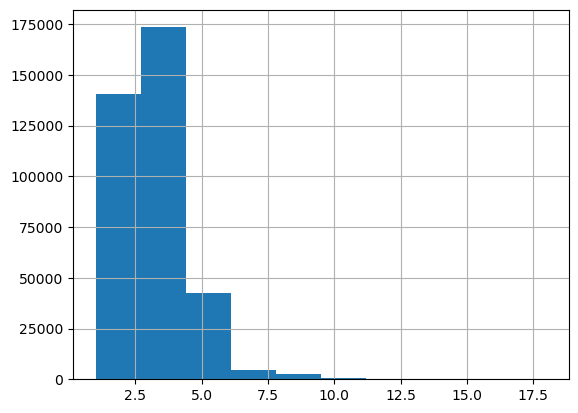

In [63]:
print("Missing N_People values:", df['N_People'].isna().sum()) # Check if missing values in N_people
df['N_People'].hist()

In [77]:
Q1 = df['N_People'].quantile(0.25)
Q3 = df['N_People'].quantile(0.75)
IQR = Q3 - Q1 # IQR = 2

upper = Q3 + 3 * IQR          # 3*IQR
df = df[df['N_People'] <= upper] # Cap to 10 people

# Gender: Adjusting enconding to 0 & 1

In [84]:
print("Missing gender values:", df['Gender'].isna().sum()) # Check if missing values in Gender
print("Average:", df['Gender'].mean()) # Looks even

# 1 = Male, 2 = Female

Missing gender values: 0
Average: 1.5272641921217562


In [86]:
# 1 = male, 2 = female  ->  male=1, female=0
df['Gender'] = df['Gender'].map({1: 1, 2: 0}).astype(int)

C:\Users\Joao\AppData\Local\Temp\ipykernel_13544\2678018168.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gender'] = df['Gender'].map({1: 1, 2: 0}).astype(int)


In [90]:
df['Gender'] # 0-1 now!

0         0
1         0
2         1
3         1
5         0
         ..
475584    0
475585    1
475586    1
475588    0
475589    1
Name: Gender, Length: 364269, dtype: int32

In [92]:
print("Average:", df['Gender'].mean()) # Looks even

Average: 0.4727358078782438


# Age: Plot and capping age at 100

Missing Age values: 0


<Axes: >

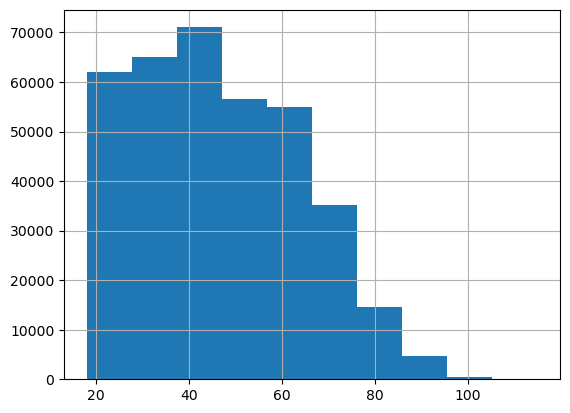

In [109]:
print("Missing Age values:", df['Age'].isna().sum()) # Check if missing values in Age
df['Age'].hist()

In [122]:
df['Age'] = df['Age'].clip(upper=100) # Cap at 100, remember that we've removed everyone below 18 as well.

C:\Users\Joao\AppData\Local\Temp\ipykernel_13544\890071848.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Age'] = df['Age'].clip(upper=100) # Cap at 100


# N_people_H: correlation with N_people

In [137]:
print(df['N_People'].corr(df['N_People_H'])) # Very high correlation, so will just drop N_people_H

0.9996553973438482


In [141]:
df = df.drop('N_People_H', axis=1)

In [145]:
df

,N_People,Gender,Age,House_Condition,Y_Study,Working,Occupation,Hours_Worked,Income
0,5,0,88,3,3.0,NaN,NaN,NaN,NaN
1,5,0,57,3,12.0,NaN,NaN,NaN,NaN
2,5,1,51,3,12.0,1.0,1.0,3.0,2500.0
3,5,1,34,3,9.0,1.0,3.0,3.0,1800.0
5,1,0,61,1,5.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
475584,4,0,47,2,8.0,NaN,NaN,NaN,NaN
475585,4,1,49,2,8.0,1.0,3.0,4.0,1500.0
475586,4,1,20,2,13.0,1.0,3.0,4.0,900.0
475588,2,0,56,2,0.0,NaN,NaN,NaN,NaN


# House_Condition: one-hot encoding

In [164]:
# It's a categorial value, something like 1: single-family, 2: multifamily

In [154]:
# One-hot encoding
house_dummies = pd.get_dummies(df['House_Condition'], prefix='HouseType',drop_first=True)   
df = pd.concat([df.drop(columns=['House_Condition']), house_dummies], axis=1)

In [158]:
house_cols = ['HouseType_2', 'HouseType_3', 'HouseType_4']
df[house_cols] = df[house_cols].astype(int)

In [167]:
df

,N_People,Gender,Age,Y_Study,Working,Occupation,Hours_Worked,Income,HouseType_2,HouseType_3,HouseType_4
0,5,0,88,3.0,NaN,NaN,NaN,NaN,0,1,0
1,5,0,57,12.0,NaN,NaN,NaN,NaN,0,1,0
2,5,1,51,12.0,1.0,1.0,3.0,2500.0,0,1,0
3,5,1,34,9.0,1.0,3.0,3.0,1800.0,0,1,0
5,1,0,61,5.0,NaN,NaN,NaN,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
475584,4,0,47,8.0,NaN,NaN,NaN,NaN,1,0,0
475585,4,1,49,8.0,1.0,3.0,4.0,1500.0,1,0,0
475586,4,1,20,13.0,1.0,3.0,4.0,900.0,1,0,0
475588,2,0,56,0.0,NaN,NaN,NaN,NaN,1,0,0


# Y_study: keeping as it is

In [178]:
print("Missing Y_study values:", df['Y_Study'].isna().sum()) # Check if missing values in Y_study

Missing Y_study values: 0


<Axes: >

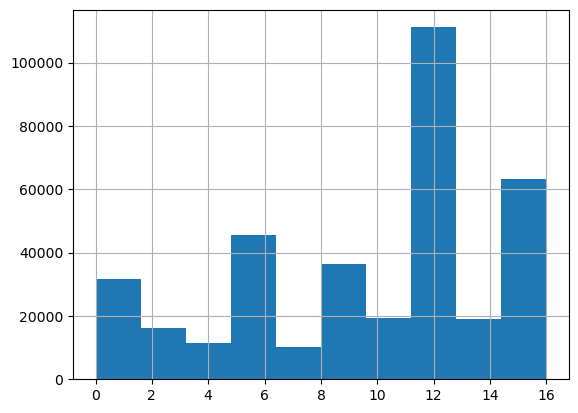

In [184]:
df['Y_Study'].hist() # Will keep it as it is

# Working: Encoding and filling missing

In [203]:
df['Working'].value_counts(dropna=False) # 1: Working, 2: Not working, N/A: "Doesn't apply"
# I don't know why there's only 11881 in 2, so I will just split into 3 categories.
# I think it's like self-employed people, etc

Working
1.0    209151
NaN    143237
2.0     11881
Name: count, dtype: int64

In [205]:
df['Working'] = df['Working'].fillna(0).astype(int) # Fillna

working_dummies = pd.get_dummies(df['Working'], prefix='Working', drop_first=False)
df = pd.concat([df.drop(columns=['Working']), working_dummies], axis=1)

In [209]:
working_cols = ['Working_0', 'Working_1', 'Working_2']
df[working_cols] = df[working_cols].astype(int)

In [214]:
df

,N_People,Gender,Age,Y_Study,Occupation,Hours_Worked,Income,HouseType_2,HouseType_3,HouseType_4,Working_0,Working_1,Working_2
0,5,0,88,3.0,NaN,NaN,NaN,0,1,0,1,0,0
1,5,0,57,12.0,NaN,NaN,NaN,0,1,0,1,0,0
2,5,1,51,12.0,1.0,3.0,2500.0,0,1,0,0,1,0
3,5,1,34,9.0,3.0,3.0,1800.0,0,1,0,0,1,0
5,1,0,61,5.0,NaN,NaN,NaN,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
475584,4,0,47,8.0,NaN,NaN,NaN,1,0,0,1,0,0
475585,4,1,49,8.0,3.0,4.0,1500.0,1,0,0,0,1,0
475586,4,1,20,13.0,3.0,4.0,900.0,1,0,0,0,1,0
475588,2,0,56,0.0,NaN,NaN,NaN,1,0,0,1,0,0


# Occupation: one-hot encoding again

In [221]:
df['Occupation'].value_counts(dropna=False)

# 1: Employee
# 2: Employer
# 3: Self-employer
# 4: Household matters
# N/A: Doesn't apply

Occupation
NaN    155118
1.0    138858
3.0     57657
2.0      8703
4.0      3933
Name: count, dtype: int64

In [223]:
df['Occupation'] = df['Occupation'].fillna(0).astype(int)

occ_dummies = pd.get_dummies(df['Occupation'], prefix='Occ', drop_first=False)
df = pd.concat([df.drop(columns=['Occupation']), occ_dummies], axis=1)

In [227]:
occ_cols = ['Occ_0', 'Occ_1', 'Occ_2', 'Occ_3', 'Occ_4']
df[occ_cols] = df[occ_cols].astype(int)

# Hours_Worked: ONE-Hot Encoding due to being a range

In [239]:
df['Hours_Worked'].value_counts(dropna=False) # One-hot encoding again b/c it's a range

Hours_Worked
NaN    155118
3.0    107295
2.0     49816
5.0     22402
4.0     16551
1.0     13087
Name: count, dtype: int64

In [241]:
df['Hours_Worked'] = df['Hours_Worked'].fillna(0).astype(int)

hours_dummies = pd.get_dummies(df['Hours_Worked'], prefix='Hours',drop_first=False)
df = pd.concat([df.drop(columns=['Hours_Worked']), hours_dummies], axis=1)

hours_cols = [c for c in df.columns if c.startswith('Hours_')]
df[hours_cols] = df[hours_cols].astype(int)

# Income

In [255]:
df['Income'].describe()

count    205043.000000
mean       3229.020386
std        4660.354185
min          10.000000
25%        1518.000000
50%        2000.000000
75%        3300.000000
max      250000.000000
Name: Income, dtype: float64

In [261]:
df['Income'].isna().sum() # Enormous amount of N/A 

159226

In [263]:
# Data is fine, despite outliers! Caped to R$250k/month

In [276]:
df.shape

(364269, 22)

Text(0.5, 1.0, 'Income distribution')

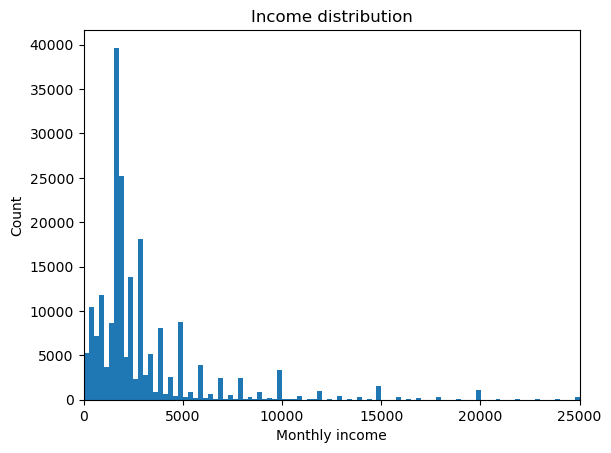

In [797]:
plt.hist(df["Income"].dropna(), bins=1000)
plt.xlim(0, 25000)   
plt.xlabel("Monthly income")
plt.ylabel("Count")
plt.title("Income distribution")

# Testing New df

In [266]:
df_train = df[df['Income'].notna()].copy()

In [270]:
df_train.shape

# 21 features, 205,043 people!

(205043, 22)

In [284]:
df_train

# Categorical: 19
# Numerical features: 3
# Income (target): Numerical

,N_People,Gender,Age,Y_Study,Income,HouseType_2,HouseType_3,HouseType_4,Working_0,Working_1,...,Occ_1,Occ_2,Occ_3,Occ_4,Hours_0,Hours_1,Hours_2,Hours_3,Hours_4,Hours_5
2,5,1,51,12.0,2500.0,0,1,0,0,1,...,1,0,0,0,0,0,0,1,0,0
3,5,1,34,9.0,1800.0,0,1,0,0,1,...,0,0,1,0,0,0,0,1,0,0
6,5,0,39,16.0,3500.0,0,1,0,0,1,...,1,0,0,0,0,0,0,1,0,0
7,5,0,37,16.0,2700.0,0,1,0,0,1,...,1,0,0,0,0,0,0,1,0,0
8,5,1,39,12.0,3000.0,0,1,0,0,1,...,1,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475581,3,1,47,12.0,3000.0,0,1,0,0,1,...,0,0,1,0,0,0,0,1,0,0
475582,3,0,54,8.0,2400.0,0,1,0,0,1,...,1,0,0,0,0,0,1,0,0,0
475585,4,1,49,8.0,1500.0,1,0,0,0,1,...,0,0,1,0,0,0,0,0,1,0
475586,4,1,20,13.0,900.0,1,0,0,0,1,...,0,0,1,0,0,0,0,0,1,0


In [303]:
df_train['Working_0'].sum() # No people "working_0" here

0

In [305]:
df_train = df_train.drop(['Working_0', 'Working_1'],axis=1) 
# Drop these two features as they are useless now. We can use them later on when we can predict people's income

In [307]:
df_train

,N_People,Gender,Age,Y_Study,Income,HouseType_2,HouseType_3,HouseType_4,Working_2,Occ_0,Occ_1,Occ_2,Occ_3,Occ_4,Hours_0,Hours_1,Hours_2,Hours_3,Hours_4,Hours_5
2,5,1,51,12.0,2500.0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0
3,5,1,34,9.0,1800.0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0
6,5,0,39,16.0,3500.0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0
7,5,0,37,16.0,2700.0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0
8,5,1,39,12.0,3000.0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475581,3,1,47,12.0,3000.0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0
475582,3,0,54,8.0,2400.0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0
475585,4,1,49,8.0,1500.0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0
475586,4,1,20,13.0,900.0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0


# Train-test split and cross-validation

In [312]:
X = df_train.drop(columns=['Income'])
y = df_train['Income']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42) #40% as training data
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42) #30% validation, 30% test

# Tree-based Models - Random Forest Regressor

In [435]:
# Makes sense since mentioned in paper, though they did a classification task with 'Gini' Criterion

rf = RandomForestRegressor(n_estimators=400, max_depth=12, min_samples_leaf=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=12, min_samples_leaf=100, n_estimators=400,
                      random_state=42)

In [439]:
y_pred = rf.predict(X_val)          

print("Random Forest R^2:", r2_score(y_val, y_pred))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_val, y_pred)))

Random Forest R^2: 0.24295732765398437
Random Forest RMSE: 4106.595503379587


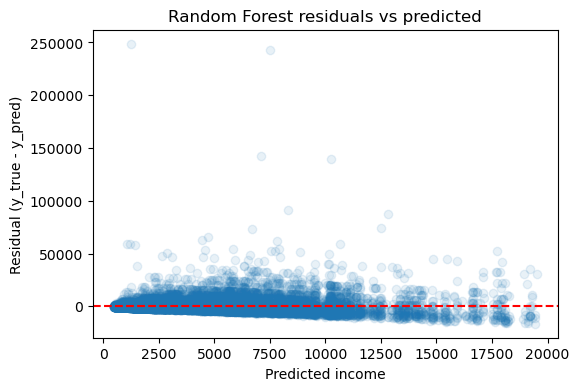

In [457]:
residuals = y_val - y_pred

plt.scatter(y_pred, residuals, alpha=0.1)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted income")
plt.ylabel("Residual (y_true - y_pred)")
plt.title("Random Forest residuals vs predicted")

Text(0.5, 1.0, 'Residual distribution')

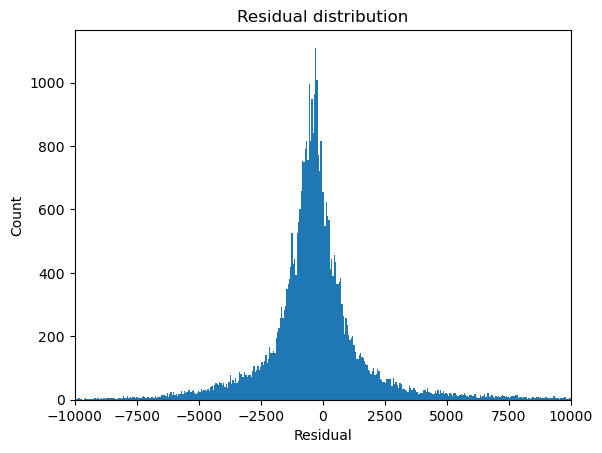

In [469]:
plt.hist(residuals, bins=5000)
plt.xlabel("Residual")
plt.xlim(-10000, 10000)
plt.ylabel("Count")
plt.title("Residual distribution")

# Residual is a bit skewed, which makes sense since income is very skewed
# When capping at R$10k residual, it looks like a normal distribution
# So, overall the model underestimates income, rather than overestimate it.

Text(0.5, 1.0, 'Random Forest tree #0')

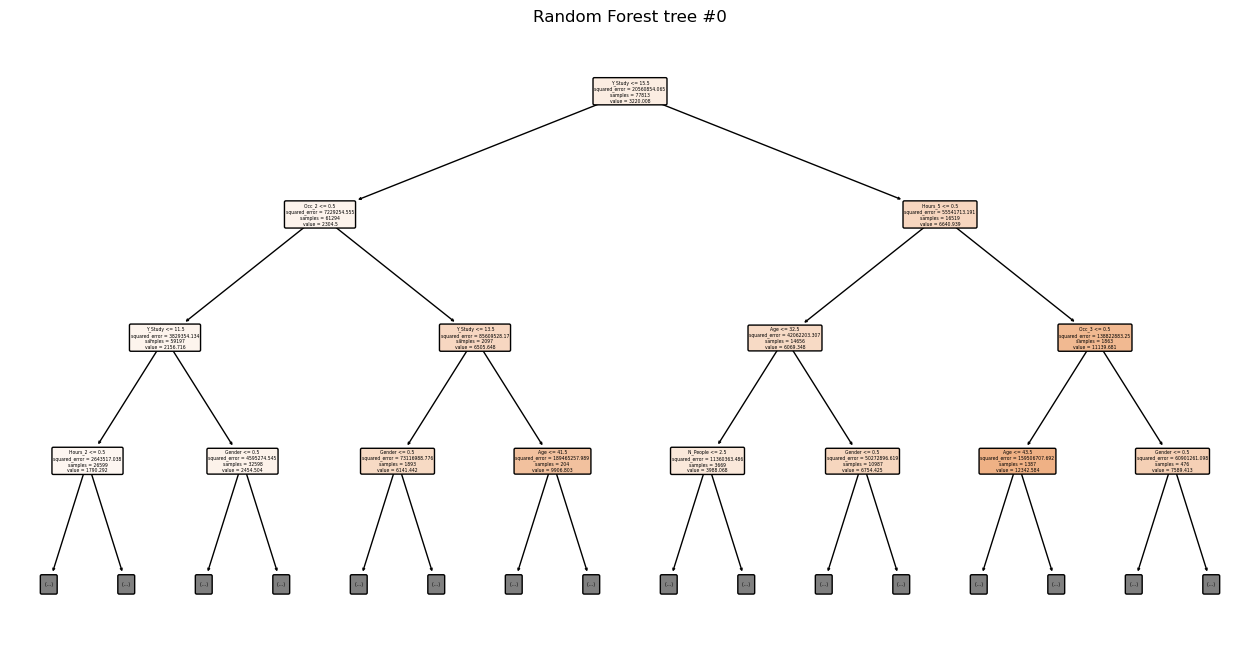

In [821]:
plt.figure(figsize=(16, 8))
plot_tree(rf.estimators_[0],feature_names=X.columns,filled=True,rounded=True,max_depth=3)
plt.title("Random Forest tree #0")

In [823]:
# Looks at years of study first, then house type and occupation first!

# Tree-based Models - Decision Tree Regressor

In [558]:
tree = DecisionTreeRegressor(max_depth=14,min_samples_leaf=200, random_state=42)

tree.fit(X_train, y_train)
y_val_pred_tree = tree.predict(X_val)

In [560]:
y_val_pred_tree = tree.predict(X_val)

print("Decision Tree R^2:", r2_score(y_val, y_val_pred_tree))
print("Decision Tree RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred_tree)))

Decision Tree R^2: 0.23715055883548408
Decision Tree RMSE: 4122.314893672424


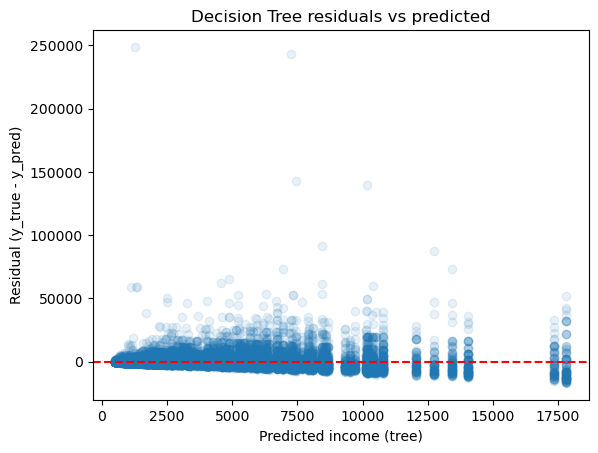

In [562]:
residuals_tree = y_val - y_val_pred_tree

plt.scatter(y_val_pred_tree, residuals_tree, alpha=0.1)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted income (tree)")
plt.ylabel("Residual (y_true - y_pred)")
plt.title("Decision Tree residuals vs predicted")
plt.show()

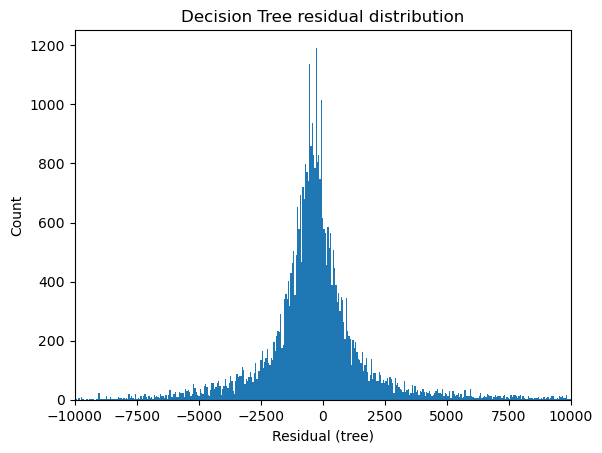

In [574]:
plt.hist(residuals_tree, bins=5000)
plt.xlim(-10000, 10000)
plt.xlabel("Residual (tree)")
plt.ylabel("Count")
plt.title("Decision Tree residual distribution")
plt.show()

Text(0.5, 1.0, 'Decision Tree - top 3')

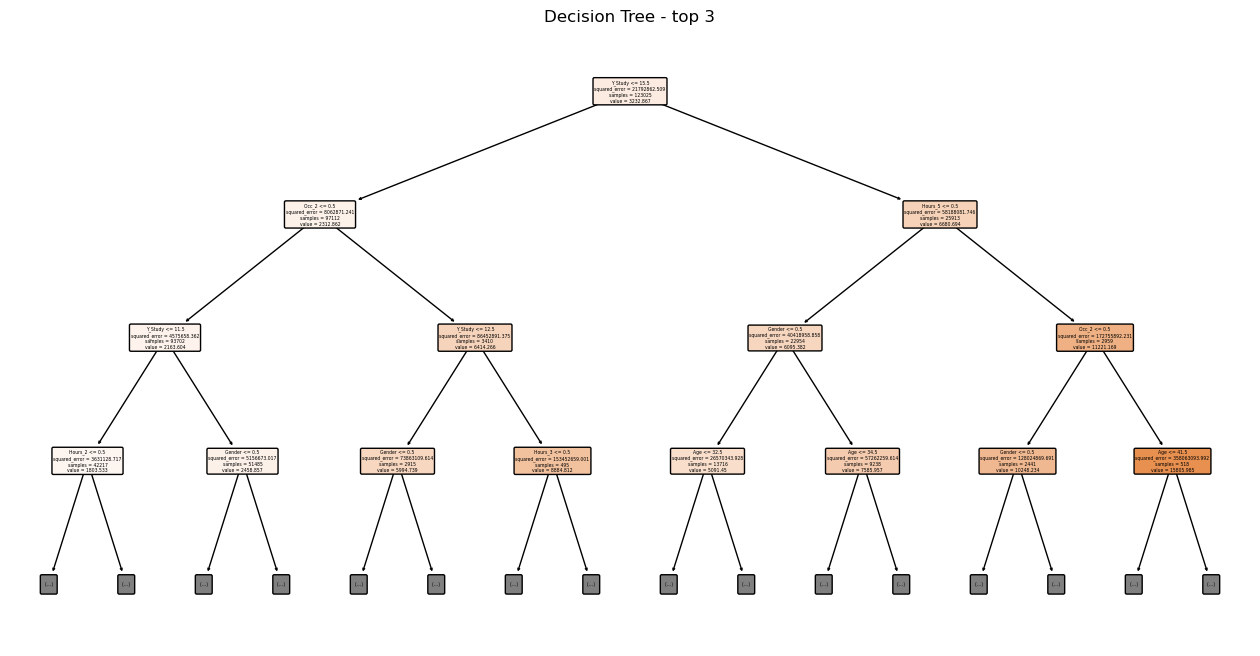

In [825]:
plt.figure(figsize=(16, 8))
plot_tree(tree,feature_names=X.columns,filled=True,rounded=True,max_depth=3)
plt.title("Decision Tree - top 3")

In [ ]:
# Looks at Years of study, then occupation and house type

# Tree-based models - Gradient Boosting

In [630]:
gbr = GradientBoostingRegressor(learning_rate=0.1,n_estimators=100,max_depth=3,random_state=42)

gbr.fit(X_train, y_train)

y_val_pred_gbr = gbr.predict(X_val)

In [634]:
print("Gradient Boosting R^2:", r2_score(y_val, y_val_pred_gbr))
print("Gradient Boosting RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred_gbr)))

# I could optimize these scores by setting learning_rate=0.1, n_estimators=100, max_depth=3 (Max depth of weak trees)

Gradient Boosting R^2: 0.24221887936455833
Gradient Boosting RMSE: 4108.597880121312


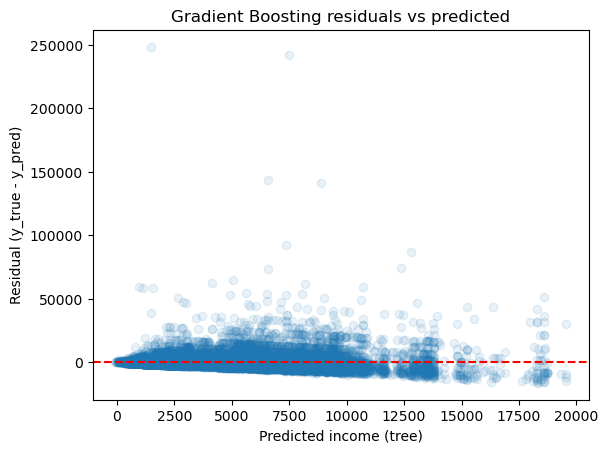

In [640]:
residuals_gbr = y_val - y_val_pred_gbr

plt.scatter(y_val_pred_gbr, residuals_gbr, alpha=0.1)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted income (tree)")
plt.ylabel("Residual (y_true - y_pred)")
plt.title("Gradient Boosting residuals vs predicted")
plt.show()

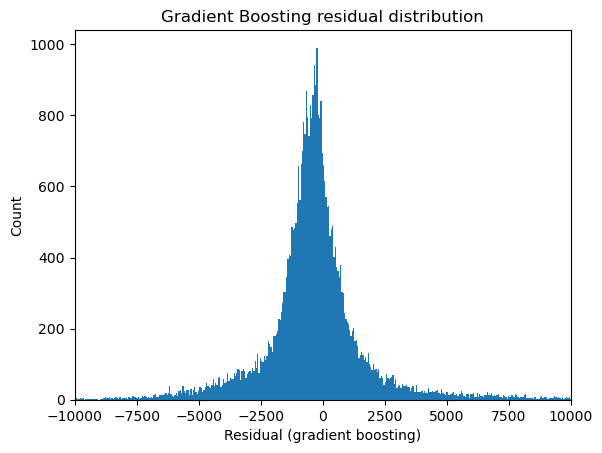

In [644]:
plt.hist(residuals_gbr, bins=5000)
plt.xlim(-10000, 10000)
plt.xlabel("Residual (gradient boosting)")
plt.ylabel("Count")
plt.title("Gradient Boosting residual distribution")
plt.show()

[Text(0.5, 0.875, 'Y_Study <= 15.5\nfriedman_mse = 21792862.509\nsamples = 123025\nvalue = -0.0'),
 Text(0.25, 0.625, 'Occ_2 <= 0.5\nfriedman_mse = 8062871.241\nsamples = 97112\nvalue = -920.005'),
 Text(0.125, 0.375, 'Y_Study <= 11.5\nfriedman_mse = 4575658.362\nsamples = 93702\nvalue = -1069.263'),
 Text(0.0625, 0.125, 'friedman_mse = 3631128.716\nsamples = 42217\nvalue = -1429.334'),
 Text(0.1875, 0.125, 'friedman_mse = 5156673.017\nsamples = 51485\nvalue = -774.01'),
 Text(0.375, 0.375, 'Y_Study <= 12.5\nfriedman_mse = 86452891.375\nsamples = 3410\nvalue = 3181.399'),
 Text(0.3125, 0.125, 'friedman_mse = 73863109.614\nsamples = 2915\nvalue = 2761.872'),
 Text(0.4375, 0.125, 'friedman_mse = 153452659.001\nsamples = 495\nvalue = 5651.945'),
 Text(0.75, 0.625, 'Hours_5 <= 0.5\nfriedman_mse = 58188081.746\nsamples = 25913\nvalue = 3447.827'),
 Text(0.625, 0.375, 'Gender <= 0.5\nfriedman_mse = 40418958.858\nsamples = 22954\nvalue = 2862.515'),
 Text(0.5625, 0.125, 'friedman_mse = 265703

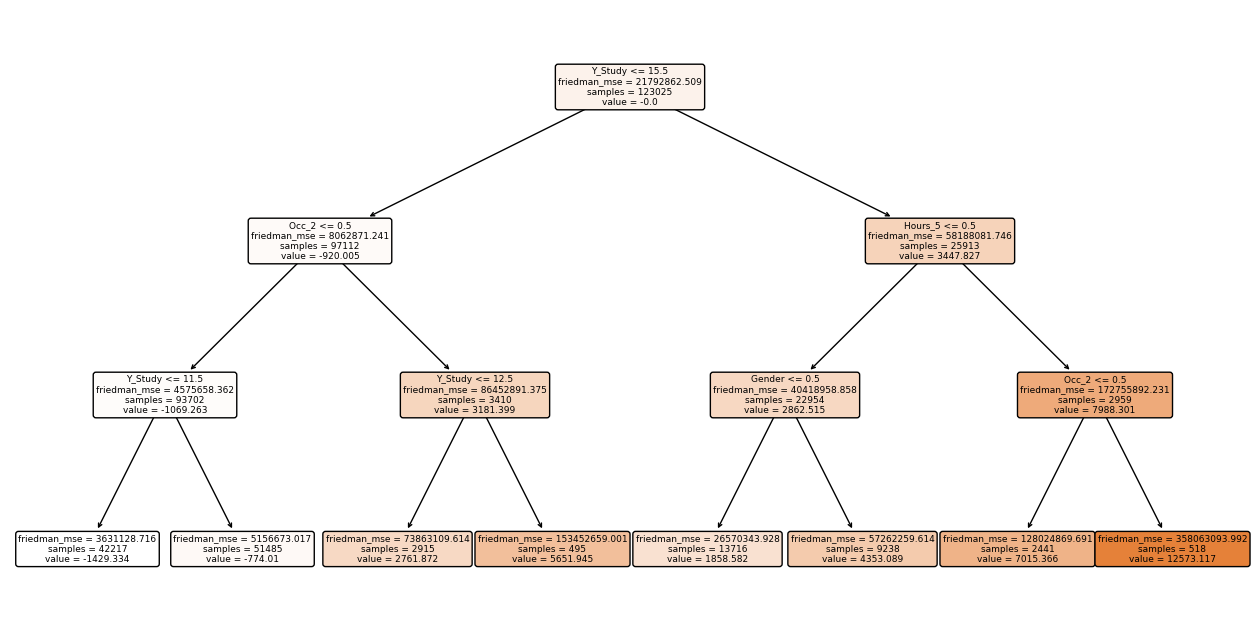

In [827]:
gbr_tree0 = gbr.estimators_[0, 0]

plt.figure(figsize=(16, 8))
plot_tree(gbr_tree0,feature_names=X.columns,filled=True,rounded=True,max_depth=3)

In [829]:
# Again, looks at years of study, then hours worked or occupation

# Regression - Ridge

In [717]:
ridge = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=0.01, random_state=42))])

In [719]:
ridge.fit(X_train, y_train)
y_val_pred_ridge = ridge.predict(X_val)

print("Ridge R^2:", r2_score(y_val, y_val_pred_ridge))
print("Ridge RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred_ridge)))

# No difference in R^2 or RMSE by changing the scaler from standard to robust or standard.
# Alpha doesn't change results as well

Ridge R^2: 0.17141163886795574
Ridge RMSE: 4296.265990023369


Text(0.5, 1.0, 'Ridge residuals vs predicted')

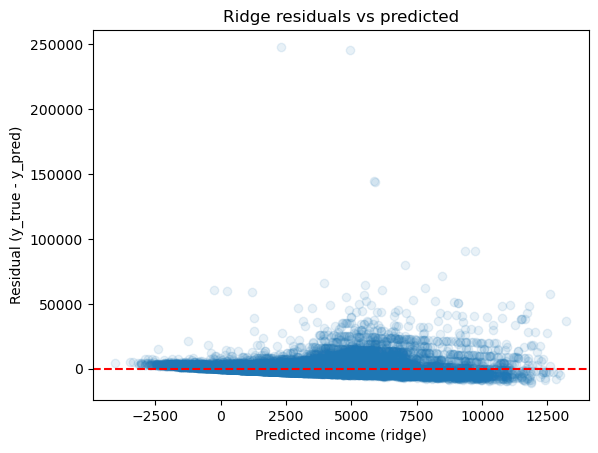

In [721]:
residuals_ridge = y_val - y_val_pred_ridge

plt.scatter(y_val_pred_ridge, residuals_ridge, alpha=0.1)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted income (ridge)")
plt.ylabel("Residual (y_true - y_pred)")
plt.title("Ridge residuals vs predicted")

Text(0.5, 1.0, 'Ridge residual distribution')

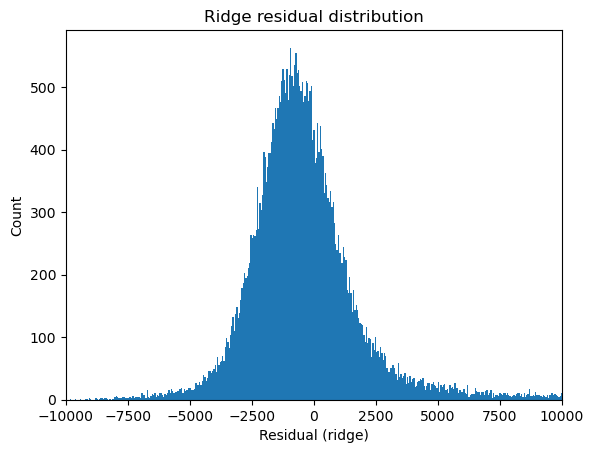

In [725]:
plt.hist(residuals_ridge, bins=5000)
plt.xlim(-10000, 10000)  
plt.xlabel("Residual (ridge)")
plt.ylabel("Count")
plt.title("Ridge residual distribution")

In [734]:
# Slightly skewed here, we can see that the residual deistribution is tending towards positive values on the right tail
# The median residual seems negative!

In [833]:
coefs = ridge.named_steps["model"].coef_
coef_df = pd.DataFrame({"feature": X.columns, "coef": coefs})

n = 5
top = coef_df.reindex(coef_df["coef"].abs().sort_values(ascending=False).index)[:n]
print(top)

    feature         coef
3   Y_Study  1622.181717
2       Age   848.669945
10    Occ_2   739.521685
1    Gender   500.680115
18  Hours_5   483.066080


In [ ]:
# They seem to make sense. More education --> more income? Age is also a good predictor.
# Type of occupation is a great predictor!
# Gender is more ambiguous, but women could be more likely to stay at home!
# Hours worked is also a good predictor

# Regression - Lasso

In [785]:
lasso = Pipeline([("scaler", RobustScaler()),("model", Lasso(alpha=0.01, max_iter=10000, random_state=42))])

In [791]:
lasso.fit(X_train, y_train)
y_val_pred_lasso = lasso.predict(X_val)

print("Lasso R^2:", r2_score(y_val, y_val_pred_lasso))
print("Lasso RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred_lasso)))

#Again, no change in alpha can change the R^2 or RMSE!

Lasso R^2: 0.17141171174293834
Lasso RMSE: 4296.265801093419


Text(0.5, 1.0, 'Lasso residuals vs predicted')

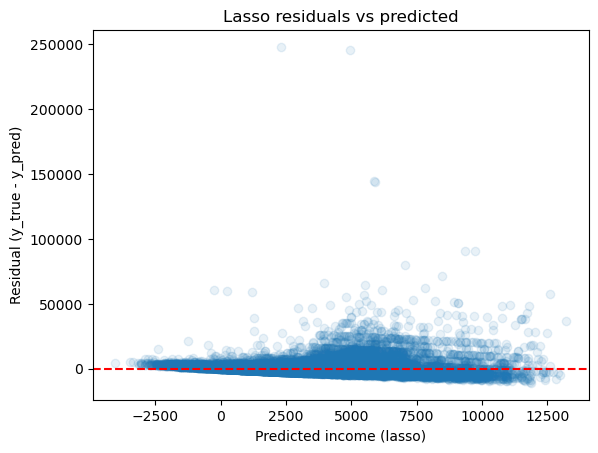

In [801]:
residuals_lasso = y_val - y_val_pred_lasso

plt.scatter(y_val_pred_lasso, residuals_lasso, alpha=0.1)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted income (lasso)")
plt.ylabel("Residual (y_true - y_pred)")
plt.title("Lasso residuals vs predicted")

# No discontinuities, the model seems more stable, though not good

In [835]:
coefs_lasso = lasso.named_steps["model"].coef_
coef_df_lasso = pd.DataFrame({"feature": X.columns, "coef": coefs_lasso})

n = 5
top_lasso = coef_df_lasso.reindex(coef_df_lasso["coef"].abs().sort_values(ascending=False).index)[:n]

print(top_lasso)

    feature         coef
10    Occ_2  3838.697261
3   Y_Study  1941.136820
18  Hours_5  1261.043316
2       Age  1258.795887
14  Hours_1 -1140.443715


In [842]:
# Similar to Ridge, all sort of similar
# Hours 1 is quite interesting: it's predicting that if hours=1 (the lower end), the person is less likely to make more money.

# Regression - Simple OLS to test (benchmark against other models)

In [846]:
ols = LinearRegression()
ols.fit(X_train, y_train)

y_val_pred_ols = ols.predict(X_val)

print("OLS R^2:", r2_score(y_val, y_val_pred_ols))
print("OLS RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred_ols)))

OLS R^2: 0.17141163763833445
OLS RMSE: 4296.265993211189


In [850]:
# Performance of simples OLS regression, so it seems like the tree-based models are performing the best,
# which makes sense since they can capture non-linearities better.

# Written Section

# Data Analysis

What does your data look like?
- Showed graphs, etc.

What's the data size? Very large. 160k samples, 420 features (could possibly add more features).
I didn't add more features because I thought that the data processing part would get very complicated, as I would have clean one-by-one, so I divided into the features I thought would make the most sense.

What's your feature space? ~22 features, mentioned before.

What data preprocessing steps did you perform? IQR, transformation (different scalers for regression models), one-hot encoding, setting 100> age > 18, etc.

What is the distribution of the target variable? Very skewed as shown in the graph

# Model Exploration

Which model(s) do you use?
Trees: DecisionTreeRegressor, RandomForestRegressor, Gradient Boosting
Regressors: Lasso, Ridge, OLS.

For each model, what parameter settings do you choose? Did that already, but I basically tested for the values that optimized R^2 and RMSE in validation to set parameters.

Interpret the model performance: Yes, wrote comments

Error analysis: 
In every plot, I think it's very clear that we underestimate and overestimate valus sometimes. For instance, we can see various models wrongfly predicted the R$250,000/monthly income at a lower level.

A few models tended to place them in small "categories" like the GradientBooster and Decision Tree.
Overall, the tree-based models worked better because they could capture the non-linearities better than the linear  models.

# Solutions to errors: Increase features selection and explore new models.

I think maybe the features are lacking, perhaps adding a lot more features and then performing some sort of dimensionality-reduction seems the best way to approach this problem.

Then, with these new pre-processed features, I would want to test new models and apply the current ones we have to see any improvements.

Despite that, income is somewhat difficult to predict and faulty sometimes, so it's not that bad of a result I think, given it's very skewed, people sometimes don't even know their income, or may want to hide it.

Another problem, perhaps I could have included the missing income in some different way to check that.

To fix these, I will also talk to faculty to make sure I have come up with all possible ideas.

In [860]:
# Tree-based models are performing better, despite the disapointing results. Will reach out soon to improve my model.

In [862]:
# Decision trees more robust, though, as expected, since data is non linear.